Pensamos en t como el tiempo y en x como la posición de una partícula imaginaria que se mueve a lo largo de la recta real, y $\dot{x}$ como la velocidad de esa partícula. Entonces, la ecuación diferencial $\dot{x} = \sin x$ representa un *campo vectorial* en la recta: dicta el vector velocidad $\dot{x}$ en cada *x*. Para esbozar el campo vectorial, es conveniente graficar $\dot{x}$ frente a *x*, y luego dibujar flechas sobre el eje *x* para indicar el vector velocidad correspondiente en cada *x*. Las flechas apuntan hacia la derecha cuando $\dot{x} > 0$ y hacia la izquierda cuando $\dot{x} < 0$.


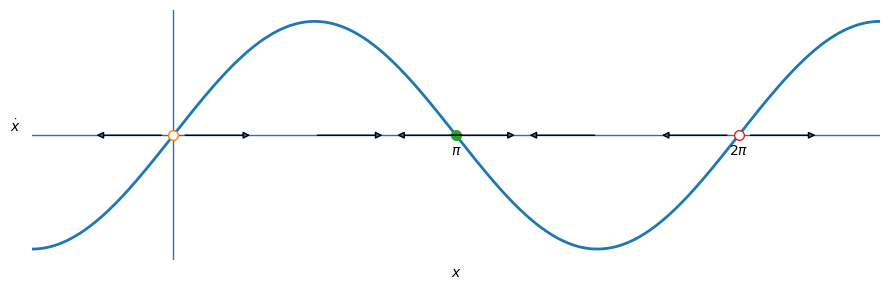

In [18]:
import numpy as np
import matplotlib.pyplot as plt

xmin = -0.5*np.pi
xmax = 2.5*np.pi
x = np.linspace(xmin, xmax, 1000)
xdot = np.sin(x)

fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(x, xdot, linewidth=2)

ax.axvline(0, linewidth=1)
ax.axhline(0, linewidth=1)

# Puntos de equilibrio en k*pi
k_min = int(np.floor(xmin/np.pi))
k_max = int(np.ceil(xmax/np.pi))
eq_points = [k*np.pi for k in range(k_min, k_max+1)]

for k, x0 in enumerate(eq_points):
    stable = np.cos(x0) < 0
    if xmin <= x0 <= xmax:
        if stable:
            ax.plot(x0, 0, 'o', markersize=7)             
        else:
            ax.plot(x0, 0, 'o', markersize=7, markerfacecolor='white')

# Flechas sobre el eje x indicando la dirección (signo de sin x)
# Entre ceros consecutivos, \sin x mantiene el signo
for a, b in zip(eq_points[:-1], eq_points[1:]):
    if b < xmin or a > xmax:       # fuera de rango visible
        continue
    mid = 0.5*(a+b)
    sign = np.sign(np.sin(mid))    # +1 derecha, -1 izquierda
    # Colocamos varias flechas por segmento
    n_arrows = 3
    xs = np.linspace(a+0.1, b-0.1, n_arrows)  # evite pegarse al punto
    for xi in xs:
        dx = 0.25*(b-a)*sign       # longitud de flecha proporcional al intervalo
        ax.annotate(
            '', xy=(xi+dx, 0), xytext=(xi, 0),
            arrowprops=dict(arrowstyle='-|>', linewidth=1)
        )

# Etiquetas en π y 2π (opcional)
def put_pi_label(val, text):
    if xmin <= val <= xmax:
        ax.text(val, -0.08, text, ha='center', va='top')

put_pi_label(np.pi, r'$\pi$')
put_pi_label(2*np.pi, r'$2\pi$')

# Etiquetas de ejes
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\dot{x}$', rotation=0, labelpad=12)

# Límites y aspecto visual
ax.set_xlim(xmin, xmax)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()
